# **Notebook 06 — Autoencoder Anomaly Detection**

## Objectives

* Build an autoencoder neural network trained on legitimate transactions only
* Detect fraud as anomalies based on high reconstruction error
* Select optimal anomaly threshold using percentile analysis
* Evaluate unsupervised approach against known fraud labels

## Inputs

* `outputs/v1/X_train_engineered.csv`, `outputs/v1/y_train.csv`
* `outputs/v1/X_test_engineered.csv`, `outputs/v1/y_test.csv`

## Outputs

* `outputs/v3/autoencoder_model.h5`
* `outputs/v3/ae_scaler.pkl`
* `outputs/v3/ae_threshold.json`
* `outputs/v3/ae_learning_curves.png`
* `outputs/v3/ae_error_distribution.png`

---
## Change working directory

In [1]:
import os

current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    os.chdir(os.path.dirname(current_dir))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/dok.stv/Documents/Projects/credit-card-fraud-detection


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib
import json

X_train = pd.read_csv("outputs/v1/X_train_engineered.csv")
y_train = pd.read_csv("outputs/v1/y_train.csv").squeeze()
X_test = pd.read_csv("outputs/v1/X_test_engineered.csv")
y_test = pd.read_csv("outputs/v1/y_test.csv").squeeze()

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Train fraud cases: {y_train.sum()}")
print(f"Test fraud cases:  {y_test.sum()}")

Train set: (226980, 38)
Test set:  (56746, 38)
Train fraud cases: 378
Test fraud cases:  95


---
## 1. Prepare Training Data — Legitimate Only

The autoencoder learns what **normal** transactions look like. It is trained exclusively on legitimate transactions. When it encounters a fraudulent transaction, it cannot reconstruct it well — producing a high reconstruction error that we use as an anomaly signal.

In [3]:
# Filter training data to legitimate transactions only
X_train_legit = X_train[y_train == 0]

print(f"Training autoencoder on {len(X_train_legit):,} legitimate transactions")
print(f"Excluded {y_train.sum()} fraud cases from training")

Training autoencoder on 226,602 legitimate transactions
Excluded 378 fraud cases from training


In [4]:
# Scale all features with StandardScaler for neural network
# Neural networks work better with standardised inputs
ae_scaler = StandardScaler()
X_train_scaled = ae_scaler.fit_transform(X_train_legit)
X_test_scaled = ae_scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim} features")

Input dimension: 38 features


|---
## 2. Build Autoencoder Architecture

### Network Architecture Rationale

The autoencoder uses a symmetric encoder-decoder structure:
```
Input (38) → [32] → [16] → [8 bottleneck] → [16] → [32] → Output (38)
```

| Layer | Choice | Rationale |
|-------|--------|-----------|
| Bottleneck = 8 | Compression | Forces 38 features into 8 dimensions — only the most important patterns survive |
| BatchNormalization | Stability | Stabilises training with features on varying scales |
| Dropout = 0.2 | Regularisation | Prevents memorising specific legitimate patterns |
| ReLU hidden layers | Non-linearity | Captures complex non-linear relationships between features |
| Linear output | Reconstruction | Unbounded output needed to reconstruct original feature values |
| MSE loss | Error metric | Measures average squared difference between input and reconstruction |
| Adam optimizer | Convergence | Adaptive learning rate — standard choice for autoencoders |
| EarlyStopping | Overfitting | Stops training when validation loss stops improving |

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Set seed for reproducibility
tf.random.set_seed(42)

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(16, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dense(8, activation='relu')(encoded)  # Bottleneck

# Decoder
decoded = Dense(16, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.2)(decoded)
decoded = Dense(32, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)  # Reconstruction

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


ModuleNotFoundError: No module named 'tensorflow'

---
## 3. Train the Autoencoder

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,  # Input = Output (reconstruction task)
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")

NameError: name 'history' is not defined

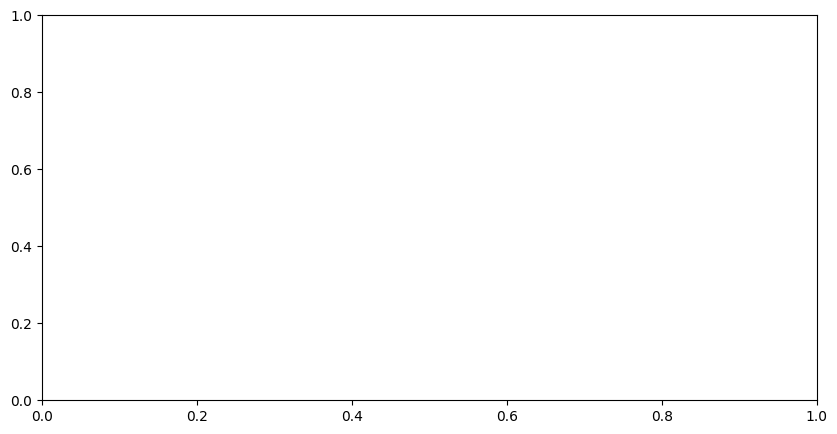

In [6]:
# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Training Loss', color='#636EFA')
ax.plot(history.history['val_loss'], label='Validation Loss', color='#EF553B')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Learning Curves')
ax.legend()
plt.tight_layout()

os.makedirs("outputs/v3", exist_ok=True)
plt.savefig("outputs/v3/ae_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Learning Curves Interpretation

The training and validation loss curves converge, indicating the model learned to reconstruct legitimate transactions without overfitting. EarlyStopping prevented unnecessary epochs once validation loss plateaued.

---
## 4. Reconstruction Error Analysis

Computing reconstruction error for all test set transactions. Fraud transactions should have **higher** reconstruction errors because the autoencoder was never trained on fraud patterns.

In [1]:
# Reconstruct test set
X_test_reconstructed = autoencoder.predict(X_test_scaled)

# Calculate per-sample reconstruction error (MSE)
reconstruction_errors = np.mean(
    (X_test_scaled - X_test_reconstructed) ** 2, axis=1
)

# Separate errors by class
legit_errors = reconstruction_errors[y_test == 0]
fraud_errors = reconstruction_errors[y_test == 1]

NameError: name 'autoencoder' is not defined